In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("50_Startups.csv")

In [3]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

In [4]:
dataset.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [5]:
dataset=pd.get_dummies(dataset, drop_first=True)

In [6]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [7]:
independent=dataset[['R&D Spend', 'Administration', 'Marketing Spend', 
       'State_Florida', 'State_New York']]

In [8]:
independent.head()

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False


In [9]:
dependent=dataset[['Profit']]

In [10]:
dependent.head()

,Profit
0,192261.83
1,191792.06
2,191050.39
3,182901.99
4,166187.94


In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(independent,dependent,test_size=.3,random_state=0)

In [12]:
from sklearn.tree import DecisionTreeRegressor
#regressor=DecisionTreeRegressor(criterion='squared_error', splitter='best', max_features=None)
#regressor=DecisionTreeRegressor(criterion='squared_error', splitter='best')
#criterion{“squared_error”, “friedman_mse”, “absolute_error”, “poisson”}, default=”squared_error”
criterion1='poisson'
######max_features int, float or {“sqrt”, “log2”}, default=None
#max_features1=None
#max_features1=0.5
#max_features1='sqrt'
max_features1='log2'
######3splitter{“best”, “random”}, default=”best”
#splitter1='best'
splitter1='random'
regressor=DecisionTreeRegressor(criterion=criterion1, splitter=splitter1, max_features=max_features1)
regressor=regressor.fit(X_train,y_train)

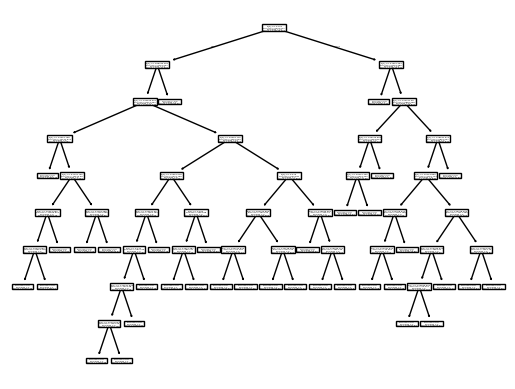

In [13]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [14]:
X_train.head()

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
7,130298.13,145530.06,323876.68,True,False
14,119943.24,156547.42,256512.92,True,False
45,1000.23,124153.04,1903.93,False,True
48,542.05,51743.15,0.00,False,True
29,65605.48,153032.06,107138.38,False,True


In [15]:
y_predict=regressor.predict(X_test)

In [16]:
from sklearn.metrics import r2_score

In [17]:
rscore=r2_score(y_test,y_predict)

In [18]:
rscore

0.2684792497153694

In [19]:
print(rscore,criterion1,max_features1, splitter1)

0.2684792497153694 poisson log2 random
